In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\Admin\Downloads\combined\combined data TE\combined_all_data_less_than_40.csv")
df

,Formula,Temperature (K),TC,DOI
0,Sn60.05Se39.95,316.000000,0.886400,10.1016/j.jallcom.2016.01.190
1,Sn60.05Se39.95,367.000000,0.772300,NaN
2,Sn60.05Se39.95,422.000000,0.688100,NaN
3,Sn60.05Se39.95,471.000000,0.675500,NaN
4,Sn60.05Se39.95,522.000000,0.597300,NaN
...,...,...,...,...
13093,Ba1.80723In1.80723Co24.0964Sb72.2892,749.928977,2.470238,NaN
13094,Ba1.80723In1.80723Co24.0964Sb72.2892,775.142045,2.488095,NaN
13095,Ba1.80723In1.80723Co24.0964Sb72.2892,800.000000,2.507143,NaN
13096,Ba1.80723In1.80723Co24.0964Sb72.2892,825.213068,2.525000,NaN


In [ ]:
import re
import pandas as pd


PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def formula_to_percent_dict(formula: str):
    f = str(formula).replace(" ", "")
    tokens = PATTERN.findall(f)
    if not tokens:
        raise ValueError(f"Không parse được công thức: {formula}")

    elems, amounts = [], []
    for el, num in tokens:
        elems.append(el)
        if num == "":
            amounts.append(1.0)
        else:
            amounts.append(float(num))

    if len(elems) == 1 and tokens[0][1] == "":
        return {elems[0]: 100.0}

    total = sum(amounts)
    return {el: amt / total * 100.0 for el, amt in zip(elems, amounts)}

comp_dicts = df["Formula"].apply(formula_to_percent_dict)

comp_df = pd.DataFrame(comp_dicts.tolist()).fillna(0.0)

new_df = pd.concat(
    [
        df[["Formula", "Temperature (K)", "TC"]],
        comp_df
    ],
    axis=1
)

print(new_df[comp_df.columns].sum(axis=1).describe())

new_df.to_csv("tc_with_composition_parsed.csv", index=False)
print("Đã lưu file: tc_with_composition_parsed.csv")


count    1.309800e+04
mean     1.000000e+02
std      7.164587e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
dtype: float64
Đã lưu file: tc_with_composition_parsed.csv


In [5]:
new_df

,Formula,Temperature (K),TC,Sn,Se,Al,Cu,In,Pb,Na,...,Cs,Tb,Lu,Z,M,W,Rh,D,Re,Hg
0,Sn60.05Se39.95,316.000000,0.886400,60.05,39.95,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Sn60.05Se39.95,367.000000,0.772300,60.05,39.95,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Sn60.05Se39.95,422.000000,0.688100,60.05,39.95,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Sn60.05Se39.95,471.000000,0.675500,60.05,39.95,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Sn60.05Se39.95,522.000000,0.597300,60.05,39.95,0.0,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13093,Ba1.80723In1.80723Co24.0964Sb72.2892,749.928977,2.470238,0.00,0.00,0.0,0.0,1.807229,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13094,Ba1.80723In1.80723Co24.0964Sb72.2892,775.142045,2.488095,0.00,0.00,0.0,0.0,1.807229,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13095,Ba1.80723In1.80723Co24.0964Sb72.2892,800.000000,2.507143,0.00,0.00,0.0,0.0,1.807229,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13096,Ba1.80723In1.80723Co24.0964Sb72.2892,825.213068,2.525000,0.00,0.00,0.0,0.0,1.807229,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
X = new_df.drop(columns=["TC", "Formula"])

y = new_df["TC"]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (13098, 74)
y shape: (13098,)


In [4]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

print("Train:", X_train.shape)
print("Test:", X_test.shape)


Train: (10478, 74)
Test: (2620, 74)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models_and_grids = {
    "DecisionTree": (
        DecisionTreeRegressor(random_state=42),
        {
            "max_depth": [None, 6, 12, 20],
            "min_samples_split": [2, 5, 10]
        }
    ),
    "RandomForest": (
        RandomForestRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [200, 500],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),
    "ExtraTrees": (
        ExtraTreesRegressor(random_state=42, n_jobs=-1),
        {
            "n_estimators": [300, 600],
            "max_depth": [None, 12, 20],
            "min_samples_split": [2, 5]
        }
    ),
    "GradientBoosting": (
        GradientBoostingRegressor(random_state=42),
        {
            "n_estimators": [200, 500],
            "learning_rate": [0.05, 0.1],
            "max_depth": [2, 3, 4]
        }
    ),

    "XGBoost": (
        XGBRegressor(
            random_state=42, n_estimators=300, tree_method="hist", n_jobs=-1,
            eval_metric="rmse"
        ),
        {
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    ),
    "CatBoost": (
        CatBoostRegressor(
            random_state=42, silent=True, loss_function="RMSE"
        ),
        {
            "iterations": [500, 800],
            "depth": [4, 6, 8],
            "learning_rate": [0.05, 0.1],
            "l2_leaf_reg": [1, 3, 5]
        }
    ),
}



In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

results = []

def r2_rmse_mae(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return r2, rmse, mae

for name, (estimator, grid) in models_and_grids.items():
    print(f"\n===== {name} =====")

    gs = GridSearchCV(
        estimator=estimator,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        n_jobs=-1,
        refit=True,
        verbose=0
    )
    gs.fit(X_train, y_train)

    best = gs.best_estimator_

    y_pred_tr  = best.predict(X_train)
    y_pred_te  = best.predict(X_test)

    r2_tr,  rmse_tr,  mae_tr  = r2_rmse_mae(y_train, y_pred_tr)
    r2_te,  rmse_te,  mae_te  = r2_rmse_mae(y_test, y_pred_te)

    results.append({
        "model": name,
        "best_params": gs.best_params_,

        "R2_train": r2_tr,   "RMSE_train": rmse_tr,   "MAE_train": mae_tr,
        "R2_test": r2_te,    "RMSE_test": rmse_te,    "MAE_test": mae_te
    })

res_df = pd.DataFrame(results).sort_values("RMSE_test")
res_df



===== DecisionTree =====

===== RandomForest =====

===== ExtraTrees =====

===== GradientBoosting =====

===== XGBoost =====

===== CatBoost =====


,model,best_params,R2_train,RMSE_train,MAE_train,R2_test,RMSE_test,MAE_test
5,CatBoost,"{'depth': 8, 'iterations': 800, 'l2_leaf_reg':...",0.990528,0.258743,0.158067,0.981458,0.371626,0.203364
2,ExtraTrees,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.999415,0.064318,0.004801,0.980656,0.379580,0.134923
1,RandomForest,"{'max_depth': None, 'min_samples_split': 2, 'n...",0.994051,0.205053,0.072106,0.976276,0.420363,0.175350
4,XGBoost,"{'colsample_bytree': 0.8, 'learning_rate': 0.1...",0.987521,0.296986,0.185760,0.975621,0.426126,0.236659
0,DecisionTree,"{'max_depth': None, 'min_samples_split': 2}",0.999415,0.064318,0.004801,0.965237,0.508844,0.221341
3,GradientBoosting,"{'learning_rate': 0.1, 'max_depth': 4, 'n_esti...",0.972607,0.440009,0.283109,0.961037,0.538709,0.325848


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

best_row = res_df.iloc[0]
best_model_name = best_row["model"]
print(f"Best Model: {best_model_name}")
print("Best Params:", best_row["best_params"])

model_class = type(models_and_grids[best_model_name][0])

best_estimator = model_class(**best_row["best_params"])

best_estimator.fit(X_train, y_train)


if hasattr(best_estimator, "feature_importances_"):
    importances = best_estimator.feature_importances_
    feat_imp = pd.Series(importances, index=X_train.columns)

    # Lấy 20 features quan trọng nhất (nếu <20 thì lấy hết)
    topk = feat_imp.nlargest(20)
    # Đảo chiều để vẽ thanh từ nhỏ -> lớn cho đẹp mắt
    topk = topk.iloc[::-1]

    plt.figure(figsize=(8, 6))
    sns.barplot(x=topk, y=topk.index)
    plt.title(f"Feature Importances - {best_model_name}", fontsize=14)
    plt.xlabel("Importance Score")
    plt.ylabel("Features")
    plt.tight_layout()
    plt.show()
else:
    print(f"Model '{best_model_name}' không hỗ trợ feature_importances_.")


Best Model: CatBoost
Best Params: {'depth': 8, 'iterations': 800, 'l2_leaf_reg': 1, 'learning_rate': 0.1}
0:	learn: 2.4958512	total: 9.66ms	remaining: 7.71s
1:	learn: 2.3549513	total: 18.2ms	remaining: 7.25s
2:	learn: 2.2286397	total: 27ms	remaining: 7.18s
3:	learn: 2.1213422	total: 36.6ms	remaining: 7.29s
4:	learn: 2.0201284	total: 46ms	remaining: 7.31s
5:	learn: 1.9383016	total: 54.6ms	remaining: 7.23s
6:	learn: 1.8607010	total: 63.8ms	remaining: 7.23s
7:	learn: 1.7959487	total: 72.3ms	remaining: 7.16s
8:	learn: 1.7390727	total: 83.9ms	remaining: 7.38s
9:	learn: 1.6825303	total: 93.2ms	remaining: 7.36s
10:	learn: 1.6339808	total: 102ms	remaining: 7.32s
11:	learn: 1.5930675	total: 112ms	remaining: 7.34s
12:	learn: 1.5558357	total: 120ms	remaining: 7.26s
13:	learn: 1.5227670	total: 128ms	remaining: 7.19s
14:	learn: 1.4892869	total: 136ms	remaining: 7.12s
15:	learn: 1.4572096	total: 144ms	remaining: 7.07s
16:	learn: 1.4333509	total: 152ms	remaining: 6.99s
17:	learn: 1.4130071	total: 160

CatBoostRegressor(depth=8, iterations=800, l2_leaf_reg=1, learning_rate=0.1, loss_function='RMSE')

In [17]:
! pip install shap



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import shap
import numpy as np
import matplotlib.pyplot as plt


c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
model = best_estimator

X_shap = X_train.sample(n=min(1000, len(X_train)), random_state=0)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_shap)


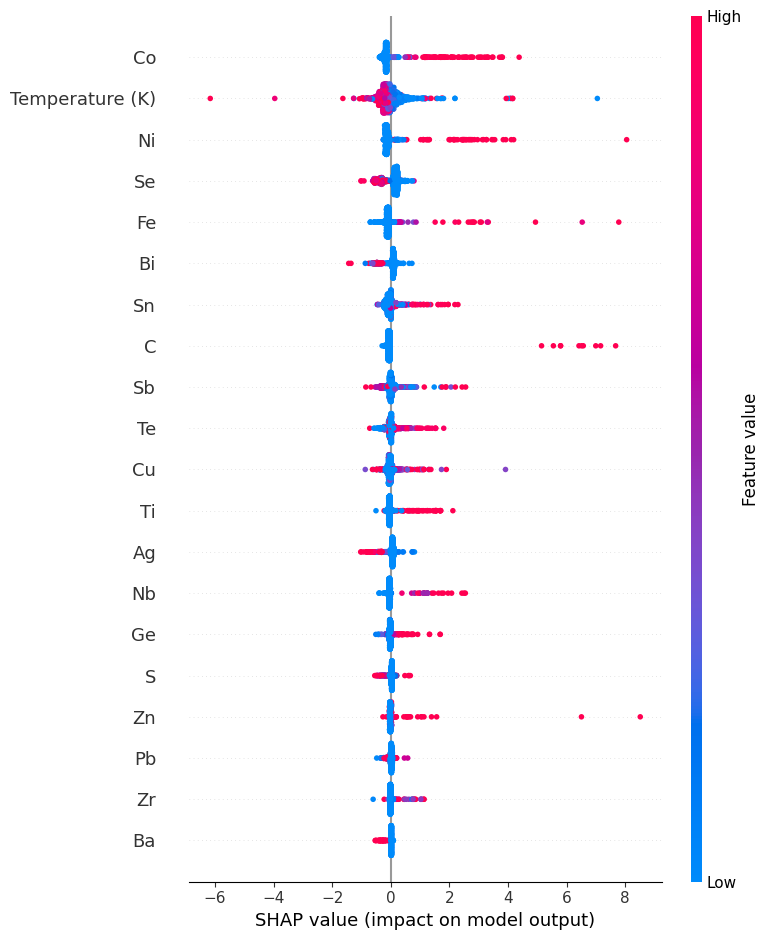

In [ ]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="dot",   
    show=True
)


In [ ]:
import numpy as np
import pandas as pd

mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

shap_df.to_csv("mean_shap_values.csv", index=False)

In [6]:
import re

PATTERN = re.compile(r'([A-Z][a-z]?)([0-9]*\.?[0-9]*)')

def formula_to_percent_dict(formula: str):
    f = str(formula).replace(" ", "")
    tokens = PATTERN.findall(f)
    if not tokens:
        raise ValueError(f"Không parse được công thức: {formula}")

    elems, amounts = [], []
    for el, num in tokens:
        elems.append(el)
        amounts.append(1.0 if num == "" else float(num))

    # 1 nguyên tố không hệ số -> 100%
    if len(elems) == 1 and tokens[0][1] == "":
        return {elems[0]: 100.0}

    total = sum(amounts)
    return {el: amt / total * 100.0 for el, amt in zip(elems, amounts)}

def make_feature_row(formula: str, temperature_K: float, feature_cols):
    comp = formula_to_percent_dict(formula)
    row = {c: 0.0 for c in feature_cols}
    if "Temperature (K)" not in row:
        raise ValueError("Thiếu cột 'Temperature (K)' trong feature_cols (X_train.columns).")

    row["Temperature (K)"] = float(temperature_K)

    # fill các nguyên tố có trong feature_cols
    for el, pct in comp.items():
        if el in row:
            row[el] = float(pct)
        # nếu el không có trong feature space thì bỏ qua (không crash)

    return pd.DataFrame([row], columns=feature_cols)

FEATURE_COLS = list(X_train.columns)


def predict_TC(formula: str, temperature_K: float):
    Xq = make_feature_row(formula, temperature_K, FEATURE_COLS)
    yhat = float(best_estimator.predict(Xq)[0])
    return yhat

In [29]:
predict_TC("Sm18.18Y3.64Yb3.64Nb3.64Ta3.64Ce3.64O63.64", 300)

1.1905938919484444